In [1]:
from src.labels import *
from src.models import *
from src.preprocessing import *
from src.splits import *
from src.train import *

In [2]:
import pandas as pd

# Show every row
pd.set_option('display.max_rows', None)

# Show every column
pd.set_option('display.max_columns', None)

# Show full content of each cell (no truncation or "...")
pd.set_option('display.max_colwidth', None)

# Prevent long frames from wrapping lines across pages
pd.set_option('display.expand_frame_repr', False)

In [3]:
data = pd.read_csv("data/parsed_save2.csv")

In [4]:
pre = preflop_data(data)
pos = position_mapping(pre)
classified = action_label(pos)
temp_with_id = classified.reset_index()
train_set, test_set = split_data_with_id_hash(temp_with_id, test_ratio=0.2, id_column="index")
x_train, y_train = x_y_separator(train_set)

In [5]:
x_train.drop(columns=["Unnamed: 0","if_fold", "result"], inplace=True)


In [6]:
x_train = hand_label(x_train)

In [7]:
x_train.drop(columns=['index','stage_flop', 'stage_pre',
       'stage_turn', 'stage_river',
       'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'hero_bet_ratio',
                      'gut_po'], inplace=True)

In [8]:
x_train.columns 1

Index(['hero_r1', 'hero_r2', 'suit_po', 'stra_po', 'position_norm',
       'facing_ratio'],
      dtype='str')

In [9]:
comparison, fitted_searches = compare_models(x_train, y_train)

C:\Users\johnl\PycharmProjects\Poker_Neural_Network\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [10]:
print(comparison)

            model  cv_macro_f1  cv_macro_f1_std  train_macro_f1  balanced_accuracy                                                                           best_parameters
3   random_forest     0.672323         0.030255        0.981314           0.672500                                                                {'model__max_depth': None}
2   decision_tree     0.661916         0.040627        0.699296           0.651303  {'model__class_weight': 'balanced', 'model__max_depth': 4, 'model__min_samples_leaf': 1}
4  support vector     0.639809         0.043321        0.837709           0.638238                                             {'model__C': 10, 'model__class_weight': None}
1        logistic     0.605318         0.041906        0.623580           0.597328                                            {'model__C': 100, 'model__class_weight': None}
0           dummy     0.223773         0.001266        0.223776           0.333333                                                     

In [11]:
print(fitted_searches)

{'dummy': GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('position',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['position_norm']),
                                                                        ('numerical',
                                                                         StandardScaler(),
                                                                         ['hero_r1',
                                                                          'hero_r2',
                      

random_forest
              precision    recall  f1-score   support

        call      0.545     0.486     0.514        37
        fold      0.643     0.537     0.585        67
       raise      0.438     0.636     0.519        33

    accuracy                          0.547       137
   macro avg      0.542     0.553     0.539       137
weighted avg      0.567     0.547     0.550       137

decision_tree
              precision    recall  f1-score   support

        call      0.640     0.432     0.516        37
        fold      0.639     0.687     0.662        67
       raise      0.450     0.545     0.493        33

    accuracy                          0.584       137
   macro avg      0.576     0.555     0.557       137
weighted avg      0.594     0.584     0.582       137

support vector
              precision    recall  f1-score   support

        call      0.449     0.595     0.512        37
        fold      0.717     0.493     0.584        67
       raise      0.476     0.60

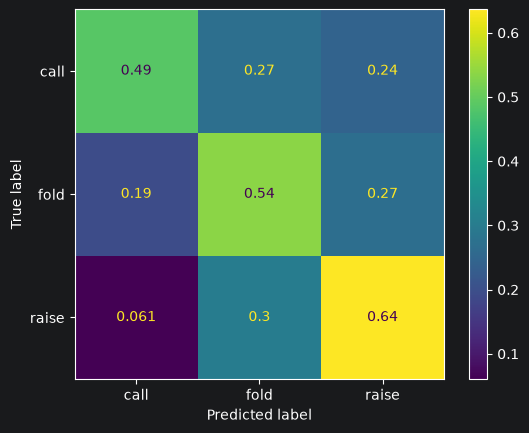

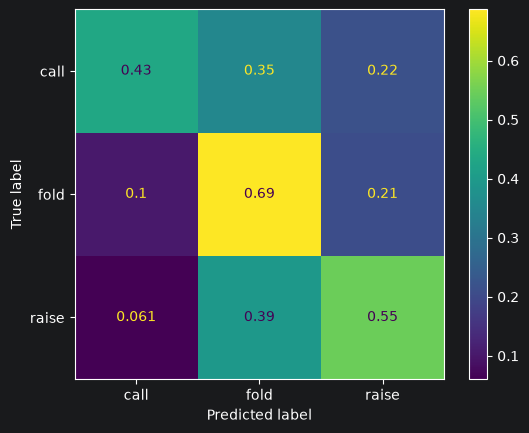

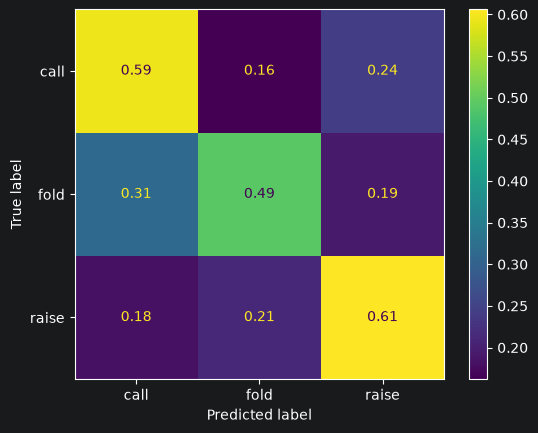

In [36]:
from src.evaluation import *
from sklearn.metrics import classification_report, f1_score
#x_test, y_test = x_y_separator(test_set)

test_result = {}
for k in range(0, 3):
    name = comparison.iloc[k]["model"]
    pipeline = fitted_searches[name].best_estimator_
    prediction = pipeline.predict(x_test)
    print(name)
    print(classification_report(y_test, prediction, digits=3, zero_division=0))
    chart = ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=pipeline.classes_,
        normalize='true',
    )
    test_result[name] = f1_score(y_test, prediction, average='macro')
#evaluate_model("artifacts/poker_action_pipeline.joblib", x_test, y_test)

In [38]:
print(test_result)
print(max(test_result, key=test_result.get))

{'random_forest': 0.5393900288209231, 'decision_tree': 0.5570500735955645, 'support vector': 0.5430106789234181}
decision_tree


In [39]:
from pathlib import Path
import joblib

best_name = max(test_result, key=test_result.get)
best_search = fitted_searches[best_name]
best_pipeline = best_search.best_estimator_

Path("artifacts").mkdir(exist_ok=True)

joblib.dump(
    best_pipeline,
    "artifacts/poker_action_pipeline.joblib",
)

print(f"Saved {best_name}: {best_search.best_params_}")

Saved decision_tree: {'model__class_weight': 'balanced', 'model__max_depth': 4, 'model__min_samples_leaf': 1}
